# Simulator For TRPL Data

In [1]:
import sys
import os
os.environ['OMP_NUM_THREADS'] = '1'

from Manuel_BayesTRPL_Utilities import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import nestle

### Oxford color scheme
base_color = "#002147"
color_scheme = ["#44687d", "#69913b", '#cf7a30', '#be0f34']
highlight_color = "#ac48bf"

line_type_list = ['-', '-.', '--', ':']

centimeters = 1/2.54
fontsize_base = 11
figure_width = 21


# Model

In [287]:
def X_n_maker(d_factor, x_size, dx, D, Sf, Sb):
    
    Xn = np.zeros((x_size, x_size))
    
    # Fill the main diagonal
    np.fill_diagonal(Xn, 1 - 2 * d_factor)

    # Fill the diagonals above and below the main diagonal
    np.fill_diagonal(Xn[1:], d_factor)
    np.fill_diagonal(Xn[:,1:], d_factor)

    # Adjust the first and last diagonal elements for boundary conditions
    Xn[0, 0] = 1 - d_factor - (dx / D) * d_factor * Sf
    Xn[-1, -1] = 1 - d_factor - (dx / D) * d_factor * Sb

    return Xn

### First: Define Rate equations
### First: Define Rate equations
def rate_equations(n_dens, nt, params):            

    k_c, k_deep, k_e, k_rad, _ = params
    
    p_dens = n_dens + nt

    R_rad = - k_rad*n_dens*p_dens
    
    dnt_dt = k_c*n_dens - k_e*nt
    R_nr = - k_c*n_dens + k_e*nt - k_deep*n_dens
    
    dn_dt = R_rad + R_nr
    

    return dn_dt, dnt_dt


def Runge_Kutta_R4(n_dens, nt, dt, params):

    RuKu1_n, RuKu1_nt = rate_equations(n_dens, nt, params)
    RuKu2_n, RuKu2_nt = rate_equations(n_dens + RuKu1_n*dt/2, nt + RuKu1_nt*dt/2, params)
    RuKu3_n, RuKu3_nt = rate_equations(n_dens + RuKu2_n*dt/2, nt + RuKu2_nt*dt/2, params)
    RuKu4_n, RuKu4_nt = rate_equations(n_dens + RuKu3_n*dt, nt + RuKu3_nt*dt, params)

    Ruku_n = (RuKu1_n + 2*RuKu2_n + 2*RuKu3_n + RuKu4_n)/6
    Ruku_nt = (RuKu1_nt + 2*RuKu2_nt + 2*RuKu3_nt + RuKu4_nt)/6

    return Ruku_n, Ruku_nt



### Looping over time-domain
def total_recombination_rate(dt_current, n_dens, p_dens, ds, params, S_f, S_b):

    _, _, _, _, D = params

    # a. Surface Recombination
    #n_dens[0] = n_dens[1] / (S_f / D * ds + 1)
    #n_dens[0] = n_dens[1] / (S_f / D * ds + 1)
    
    nt = p_dens - n_dens
    
    # b. Recombination (Runge-Kutta Algorithm)
    Ruku_n, Ruku_nt  = Runge_Kutta_R4(n_dens, nt, dt_current, params)

    # c. Diffusion
    d_factor = D * dt_current / (2 * ds * ds)

    A_n = X_n_maker(-d_factor, len(n_dens), ds, D, S_f, S_b)
    B_n = X_n_maker(d_factor, len(n_dens), ds, D, S_f, S_b)

    Bn_dot_n_dens = np.dot(B_n, n_dens + Ruku_n * dt_current)
    n_dens_new = np.dot(np.linalg.inv(A_n), Bn_dot_n_dens)

    # c. Physical limits
    n_dens_new = np.where(n_dens_new <= 0, 0, n_dens_new)
    p_dens_new = n_dens_new + nt + Ruku_nt * dt_current
    p_dens_new = np.where(p_dens_new <= 0, 0, p_dens_new)

    return n_dens_new, p_dens_new

In [315]:
def model_in_pytensor(params, time, constants, PL_err_corr):
    # Unpack Constans
    Thickness, Fluences, alphas, Svals = constants

    mu_vert, k_rad, k_deep, k_c, k_e, S1, S2  = params[:7]
    p0s = params[7:-1]

    S_front_val = np.where(Svals == 1, S1, S2)
    S_back_val = np.where(Svals == 1, S2, S1)

    ## Define the spacial and temporal domains
    z_array = np.linspace(0,Thickness,30)
    time_fit = time*1e-9

    dt = np.diff(time_fit)
    ds = np.diff(z_array)[0]   
    
    # Diffusion Coeffient in cm2 s-1
    limit_mobility = (Thickness)**2/(dt[0])/(1.380649e-23*292/1.6021766e-19)  #cm2 (Vs)-1
    Diffusion_coefficient = mu_vert*(1.380649e-23*292/1.6021766e-19)

    
    # Packing parameters
    params_iter = k_c, k_deep, k_e, k_rad, Diffusion_coefficient
    
    # Initial Charge-Carrier Density
    alphas = np.where(mu_vert >= limit_mobility/4, 0, alphas)

    generation = np.exp(-np.outer(z_array, alphas))
    generation_sum = np.sum(((generation[1:] + generation[:-1])/2), axis=0) * ds
    
    n_0z = Fluences/(generation_sum) * generation

    N_calc = P_calc = np.zeros(shape=(len(time_fit), len(z_array), len(Fluences)))

    for f, _ in enumerate(Fluences):
        
        N_calc[0,:,f] = n_0z[:,f]
        P_calc[0,:,f] = n_0z[:,f] + p0s[f]

        Sf = S_front_val[f]
        Sb = S_back_val[f]

        for t, time_diff in enumerate(dt):
            
            n_dens, p_dens = total_recombination_rate(time_diff, N_calc[t,:,f], P_calc[t,:,f], ds, params_iter, Sf, Sb)
            N_calc[t+1,:,f] = n_dens
            P_calc[t+1,:,f] = p_dens

    ## Turn radiative recombination into PL response
    Rrad_calc = N_calc * P_calc
    
    PL_calc = np.sum(((Rrad_calc[:,1:] + Rrad_calc[:,:-1])/2), axis=1) * ds

    PL_0 = PL_calc[0,:]/(1-PL_err_corr)

    PL_obs = PL_calc/PL_0 + PL_err_corr
    
    return PL_obs, N_calc, P_calc


## Main Part

### Simulated Data

In [318]:
import time as time_step

# Parameter Definition
Fluences = np.array([4.8e11,4.8e10,4.8e11,4.8e10])   #photons cm-2
alphas = np.array([3e5,3e5,3e5,3e5])  #cm-1
Thickness = 600e-7   #cm
Svals = np.array([1,1,2,2])

#constants = Thickness, Fluences, alphas, Svals

time_sim = np.append(0, np.logspace(-1,4,300)) #ns

#df_save = pd.DataFrame()
#df_save[f'Time'] = time

# mu_vert, k_rad, k_deep, k_c, k_e, S1, S2, p0s
#true_vals = 4.1e-1, 7.5e-11, 1.6e4 , 1.3e6, 7.5e5, 7.2, 3.6, 2e14, 2e15, 2e15, 2e15, 0
true_vals = p

params = true_vals
start = time_step.time()
PL, n_dens, p_dens = model_in_pytensor(params, time_sim, constants, 0.01)
stop = time_step.time()

calc_dat = PL + (-np.random.random(np.shape(PL))*0.01+0.005)
calc_dat /= PL[0,:]
print(stop-start)


0.17868518829345703


### Real Data

In [290]:
folder = r"C:\Users\kcm\Documents\GitHub\assessing-TRPL-with-bayesian-inference_and-MCMC\Example_Data\TRPL"
config_names = [r"Seo_FAPI_nuts.csv"]

laserpower_file = "2022_05_01_TRPL_Laserpower.txt" #most recent: "" , old: "2022_05_01_TRPL_Laserpower.txt"
spacing = 'log200'

df, pile_up, sample_names, Fluences, Thickness, Svals, alphas, max_arg = Bayes_TRPL_Utils(folder, config_names[0], laserpower_file)

constants = np.array(Thickness*1e-7), np.array(Fluences), np.array(alphas), np.array(Svals)


Files ready...


In [291]:
def log_time(end_point, no_points):

        fib_max = np.log(end_point-2)
        fib_list = np.logspace(0, fib_max, no_points, base=2.73)
        
        fib_list_sorted = np.unique(np.round(fib_list,0)-1)

        while fib_list_sorted[-1] > end_point:
            fib_list_sorted = fib_list_sorted[:-1]

        return np.array(fib_list_sorted).astype('int')


def logspacing(end_point, number_of_datapoints):

    len_a = 0
    nod = number_of_datapoints
    while len_a < number_of_datapoints:
        
        a = log_time(end_point, nod)
        len_a = len(a)
        nod += 1

    return a
    

def lin_time(end_point):
    return np.arange(0,end_point-2)


def spacing_choose(spacing, end_point):

    if spacing == 'linear':
        a = lin_time(end_point)

    elif 'log' in spacing:
        a = logspacing(end_point, int(spacing[3:]))

    else:
        print('spacing not implemented...')

    return a

In [292]:
def multi_exp_approximation(x, A1, A2, A3, tau1, tau2, tau3, beta2, beta3, y0):

    decay = 10**A1*np.exp(-x/tau1) + 10**A2*np.exp(-(x/tau2)**beta2) + 10**A3*np.exp(-(x/tau3)**beta3) + 10**(-y0)
    return np.sqrt(decay)

    
def setup_data_for_inference(Data_fit, a):
    #### Setting up the Data and Timeframe
    time_spline = np.array(Data_fit['Time'])  #s

    meas_dat = df.drop(columns='Time').to_numpy()

    spline_data = np.zeros(shape=(len(a), np.shape(meas_dat)[1]))
    
    #BSpline to determine sigma and smooth data
    for s in np.arange(np.shape(meas_dat)[1]):    
        data = meas_dat[:,s]

        try:
            popt, _ = curve_fit(multi_exp_approximation, time_spline, np.sqrt(data), maxfev=100000)
            spline_fit = multi_exp_approximation(time_spline, *popt)**2
        except:
            spline_data = data
        
        spline_data[:,s] = spline_fit[a]
    
    return spline_data

In [293]:
a = spacing_choose(spacing, max_arg)

spline_data = setup_data_for_inference(df, a)

time = np.array(df['Time'])[a]
meas_dat = df.drop(columns='Time').to_numpy()[a]

C:\Users\kcm\AppData\Local\Temp\ipykernel_11744\3368980754.py:3: RuntimeWarning: overflow encountered in scalar power
  decay = 10**A1*np.exp(-x/tau1) + 10**A2*np.exp(-(x/tau2)**beta2) + 10**A3*np.exp(-(x/tau3)**beta3) + 10**(-y0)
C:\Users\kcm\AppData\Local\Temp\ipykernel_11744\3368980754.py:3: RuntimeWarning: divide by zero encountered in power
  decay = 10**A1*np.exp(-x/tau1) + 10**A2*np.exp(-(x/tau2)**beta2) + 10**A3*np.exp(-(x/tau3)**beta3) + 10**(-y0)
C:\Users\kcm\AppData\Local\Temp\ipykernel_11744\3368980754.py:3: RuntimeWarning: invalid value encountered in multiply
  decay = 10**A1*np.exp(-x/tau1) + 10**A2*np.exp(-(x/tau2)**beta2) + 10**A3*np.exp(-(x/tau3)**beta3) + 10**(-y0)
C:\Users\kcm\AppData\Local\Temp\ipykernel_11744\3368980754.py:3: RuntimeWarning: invalid value encountered in power
  decay = 10**A1*np.exp(-x/tau1) + 10**A2*np.exp(-(x/tau2)**beta2) + 10**A3*np.exp(-(x/tau3)**beta3) + 10**(-y0)


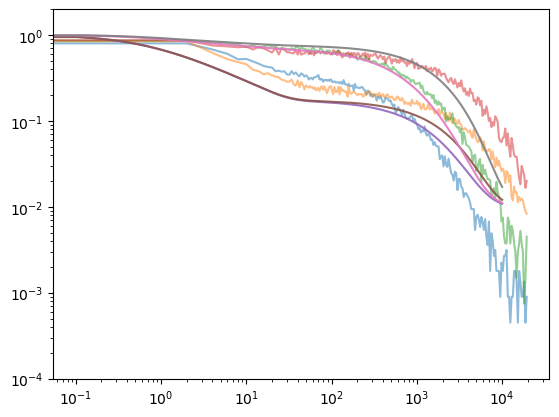

In [319]:
plt.plot(time, meas_dat, alpha=0.5)
plt.plot(time_sim, PL, alpha=0.9)
#plt.xlim(0,1e4)
plt.ylim(1e-4,2)
plt.xscale('log')
plt.yscale('log')

In [ ]:
y_obs = meas_dat
error = spline_data[-1,:]

def loglike(params):
      y_model, _, _ = model_in_pytensor(params, time, constants, error)
      #logl = -0.5*(np.nansum(((y_obs)-(y_model))**2/y_obs**2))
      y_obs_sqrt = y_obs
      y_model_sqrt = y_model
      sigma = y_obs_sqrt*params[-1]

      logl = - 0.5*np.nansum(np.log(2*np.pi*sigma**2) + ((y_obs_sqrt-y_model_sqrt)/sigma)**2)
      #return -0.5*(np.sum((y_obs-y_model)**2/y_obs**2))
      return logl

def prior_transform(p):
      # mu_vert, k_rad, k_deep, k_c, k_e, S1, S2
      
      # log10-Boundaries
      mu_vert_bound = [-2,1]
      krad_bound = [-12,-8]
      kdeep_bound = [3,7]
      kc_bound = [3,7]
      ke_bound = [3,7]
      S1_bound = [0,5]
      S2_bound = [0,5]
      p0_bound = [10,18]

      bounds = [mu_vert_bound, krad_bound, kdeep_bound, kc_bound, ke_bound, S1_bound, S2_bound]
      
      for i in np.arange(len(p)-len(bounds)-1):
            bounds.append(p0_bound)
      
      bounds.append([-2,1])

      transformed_p = ()

      for p_val, bound in zip(p, bounds):
            diff = np.abs(bound[1] - bound[0])
            transformed_p = np.append(transformed_p, 10**(diff*p_val + bound[0]))     

      return transformed_p


no_of_total_params = 7 + np.shape(meas_dat)[1] + 1
# Run nested sampling

res = nestle.sample(loglike, prior_transform, ndim=no_of_total_params, method='multi',
                    npoints=3*no_of_total_params, maxiter=300, callback=nestle.print_progress)

#pymultinest.run(loglike, prior_transform, ndims=no_of_total_params)

#res = dynesty.DynamicNestedSampler(loglike, prior_transform, ndim=7)
#res.run_nested()

C:\Users\kcm\AppData\Local\Temp\ipykernel_11744\2018526776.py:26: RuntimeWarning: overflow encountered in multiply
  R_rad = - k_rad*n_dens*p_dens
C:\Users\kcm\AppData\Local\Temp\ipykernel_11744\2018526776.py:31: RuntimeWarning: invalid value encountered in add
  dn_dt = R_rad + R_nr
C:\Users\kcm\AppData\Local\Temp\ipykernel_11744\2018526776.py:71: RuntimeWarning: invalid value encountered in dot
  Bn_dot_n_dens = np.dot(B_n, n_dens + Ruku_n * dt_current)


it=    18 logz=-29725.81064469438440812052773364748955193638279887644596797870325024912442651073816165646926923110303521314483728674294999353418807977096253141556557500613866604672769670630598323994624.000000

niter: 501
ncall: 2370
nsamples: 536
logz: 1282.556 +/-  0.697
h: 17.469
[7.31623724e+00 2.86791789e-11 4.92477956e+03 3.10088692e+05
 5.57330626e+03 4.98387257e+00 8.54513114e+00 2.40112894e+14
 1.70999078e+11 1.25837263e+16 1.79481877e+15 3.58205000e-01]


C:\Users\kcm\AppData\Local\Temp\ipykernel_11744\3137752455.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


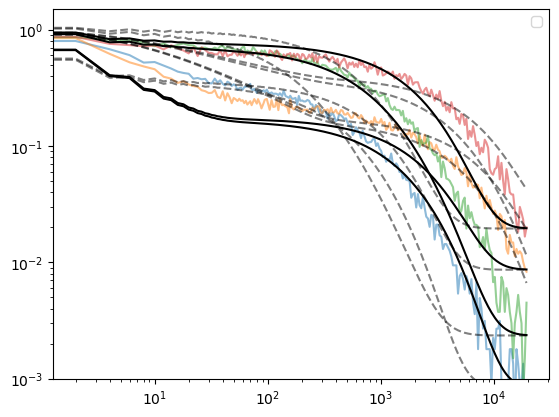

In [ ]:
samples = np.average(res.samples, weights=res.weights, axis=0)

p = np.median(res.samples[-100:,:],axis=0)
p_err_minus = np.quantile(res.samples[-100:,:], 0.05, 0)
p_err_plus = np.quantile(res.samples[-100:,:], 0.95, 0)

y_res_errm, _ , _ = model_in_pytensor(p_err_minus, time, constants, error)
y_res_median, _ , _ = model_in_pytensor(p, time, constants, error)
y_res_errp, _ , _ = model_in_pytensor(p_err_plus, time, constants, error)

print(res.summary())

print(samples)
plt.plot(time, y_obs, alpha=0.5)
plt.plot(time, y_res_median, c='k')
plt.plot(time, y_res_errm, c='k', linestyle='--', alpha=0.5)
plt.plot(time, y_res_errp, c='k', linestyle='--', alpha=0.5)
#plt.plot(time, error, linewidth=2, linestyle='--')
plt.ylim(1e-3,1.5)
plt.xscale('log')
plt.yscale('log')
plt.legend()

In [263]:
print(constants)

(array(6.e-05), array([4.823e+11, 4.823e+10, 4.823e+11, 4.823e+10]), array([300000., 300000., 300000., 300000.]), array([1, 1, 2, 2]))


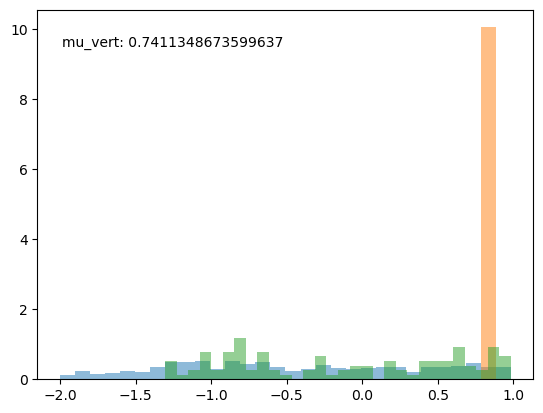

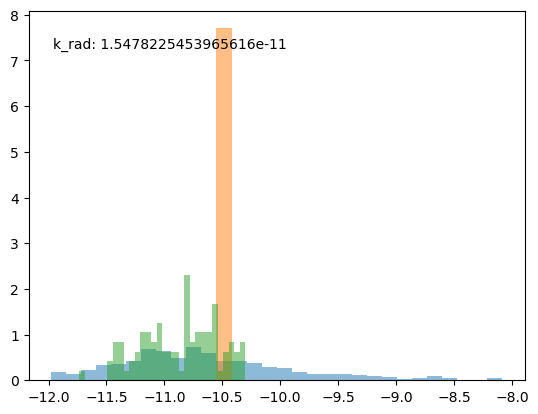

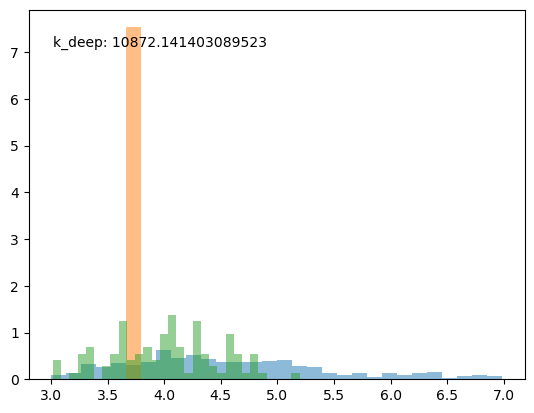

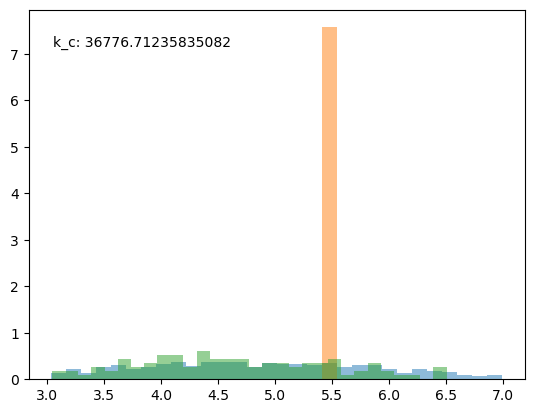

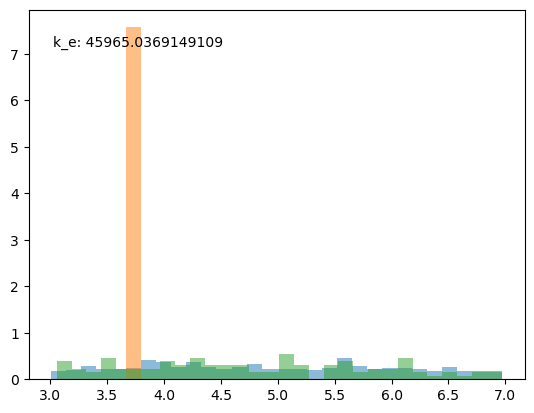

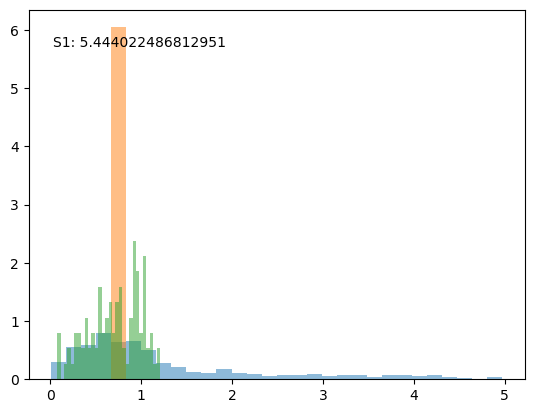

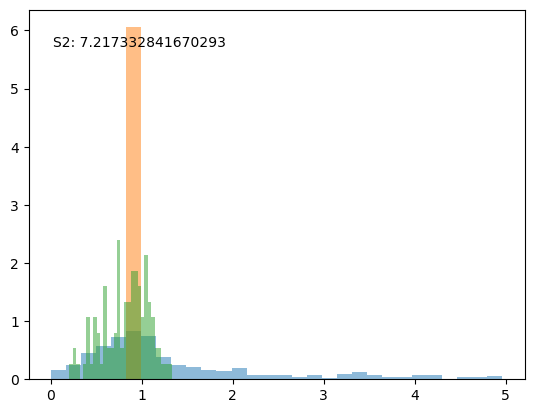

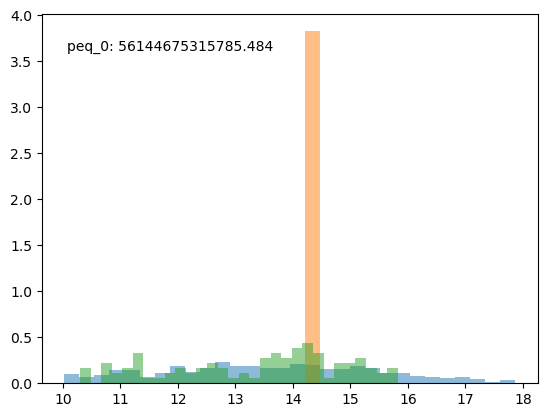

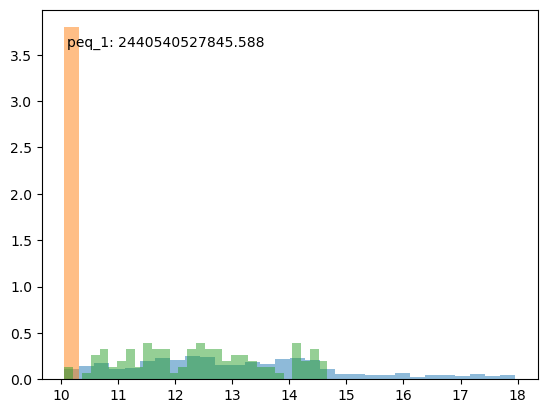

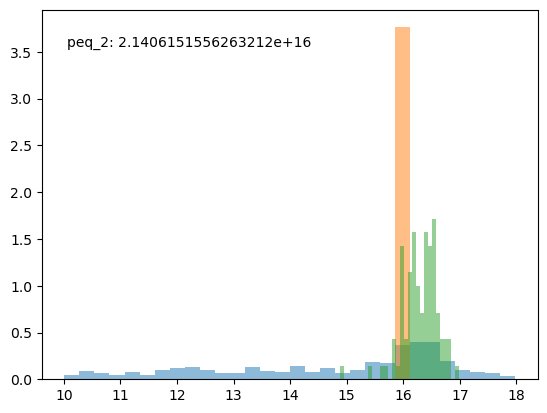

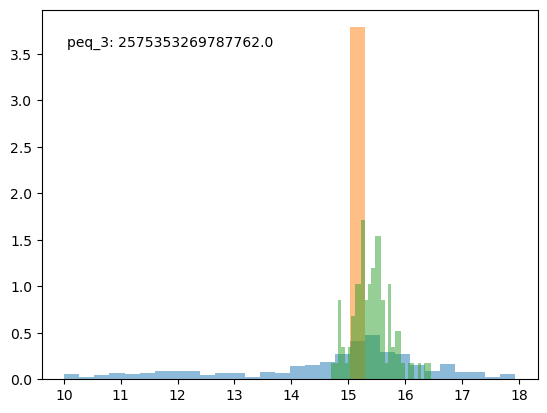

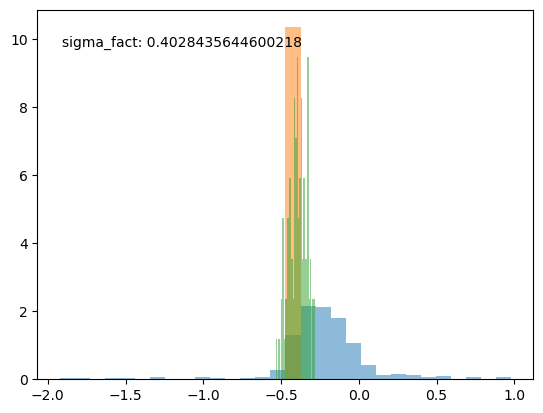

In [314]:
param_labels = ['mu_vert', 'k_rad', 'k_deep', 'k_c', 'k_e' , 'S1', 'S2']

for i in np.arange(no_of_total_params - len(param_labels)-1):
    param_labels.append(f'peq_{i}')

param_labels.append('sigma_fact')

for i, p_val in enumerate(p):
    #plt.axvline(np.log10(true_vals[i]), 0, 100, c='red', linestyle='--')
    plt.annotate(f'{param_labels[i]}: {p_val}', [0.05, 0.9], xycoords='axes fraction')
    plt.hist(np.log10(res.samples[:,i]), bins=30, density = True, alpha=0.5) 
    plt.hist(np.log10(res.samples[:,i]), bins=30, weights=res.weights, density = True, alpha=0.5)  
    plt.hist(np.log10(res.samples[-100:,i]), bins=30, density = True, alpha=0.5)
    plt.show()